# Mapping the Potential Destructive Power of Wildfires Using Machine Learning
---
## Module 8: *Evaluation and Visualization*
##### Version Number: 2.0
---
### Contents  
> 1. *Generate Case Study Predictions*
> 2. *Geospatial Visualization* (in progress)
---
### Notes
This section applies the trained models to predict wildfire severity in real-world scenarios including
- #### Palisades Fire (January 2025)  
It evaluates and compare the performance of three classification models:
- **XGBoost** (multi-class classification)
- **Random Forest**
- **K-Nearest Neighbors (KNN)**
---
### Inputs
`X.csv` Model data
`y.csv` Target data
`details.csv` details reguarding data

---
### Outputs  
- `predictions.csv` Dataset containing prediction models composed of a categorical prediction 0,1,2 to be used for interpolation in ArcGIS.
---
### User Created Dependencies  

In [1]:
# Add the parent directory to the system path so "src" can be found
import sys
import os
sys.path.append(os.path.abspath(os.path.join('..')))

# user built utilities
from src.plot_utils import plot_map
from src.plot_utils import individual_plot_map
from src.plot_utils import interpolate_idw
from src.plot_utils import interpolate_idw2

---
### Third Party Dependencies

In [2]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Modeling libraries
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
import xgboost as xgb
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import RidgeClassifier
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from sklearn.model_selection import train_test_split

# Geospatial libraries
import geopandas as gpd
from shapely.geometry import Point
import matplotlib.lines as mlines  # For custom map legends

from datetime import timedelta

In [3]:
# first day to analyze in weather dataset
FIRST_DATE = pd.to_datetime('2018-01-01').date()

# last day to analyze in weather dataset
LAST_DATE = pd.to_datetime('2024-12-31').date()

In [4]:
# Features and labels
X = pd.read_csv('../data/processed/X_reduced.csv')
y = pd.read_csv('../data/processed/y_reduced.csv').squeeze()  # Load as Series
details = pd.read_csv('../data/processed/details_reduced.csv')


In [5]:
details

,Sample_ID,Date,Region_ID,Sample_Longitude,Sample_Latitude,Region_Name,Stn_Id,Stn_Name,County,geometry_x,Stn Name,CIMIS Region,fire_count,total_fire_damage,_merge
0,1,2018-01-31,7,-117.232017,32.778837,Marine Region,173,Torrey Pines,San Diego,POINT (259634.34221583148 -577730.614588792),Torrey Pines,South Coast Valleys,0,0.0,both
1,1,2018-03-23,7,-117.232017,32.778837,Marine Region,173,Torrey Pines,San Diego,POINT (259634.34221583148 -577730.614588792),Torrey Pines,South Coast Valleys,0,0.0,both
2,1,2018-04-11,7,-117.232017,32.778837,Marine Region,173,Torrey Pines,San Diego,POINT (259634.34221583148 -577730.614588792),Torrey Pines,South Coast Valleys,0,0.0,both
3,1,2018-04-13,7,-117.232017,32.778837,Marine Region,173,Torrey Pines,San Diego,POINT (259634.34221583148 -577730.614588792),Torrey Pines,South Coast Valleys,0,0.0,both
4,1,2018-07-06,7,-117.232017,32.778837,Marine Region,173,Torrey Pines,San Diego,POINT (259634.34221583148 -577730.614588792),NaN,NaN,1,27096050.0,both
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22140,173,2025-01-19,1,-120.232017,41.778837,Northern Region,90,Alturas,Modoc,POINT (-19320.214235894404 417931.49323822185),Alturas,Northeast Plateau,0,0.0,both
22141,173,2025-01-20,1,-120.232017,41.778837,Northern Region,90,Alturas,Modoc,POINT (-19320.214235894404 417931.49323822185),Alturas,Northeast Plateau,0,0.0,both
22142,173,2025-01-21,1,-120.232017,41.778837,Northern Region,90,Alturas,Modoc,POINT (-19320.214235894404 417931.49323822185),Alturas,Northeast Plateau,0,0.0,both
22143,173,2025-01-22,1,-120.232017,41.778837,Northern Region,90,Alturas,Modoc,POINT (-19320.214235894404 417931.49323822185),Alturas,Northeast Plateau,0,0.0,both


In [6]:
y.value_counts()

Target
0    13944
2     4772
1     3429
Name: count, dtype: int64

In [7]:
details['Date'] = pd.to_datetime(details['Date']).dt.date

# Boolean mask for the date window
mask = (details['Date'] >= FIRST_DATE) & (details['Date'] <= LAST_DATE)

# MODEL (inside date range)
model_details = details.loc[mask]
model_X = X.loc[mask]
model_y = y.loc[mask]

# PAL (outside date range)
pal_details = details.loc[~mask]
pal_X = X.loc[~mask]
pal_y = y.loc[~mask]

### 1.1 Build Models

In [8]:
model_parameters = pd.read_csv('../data/processed/model_parameters.csv', index_col=0)

RF_parameters = model_parameters.loc['RandomForest'].dropna().to_dict()
XGB_parameters = model_parameters.loc['XGBoost'].dropna().to_dict()
Knn_parameters = model_parameters.loc['KNN'].dropna().to_dict()
optimal_learning_rate = XGB_parameters['learning_rate']

In [9]:
# Helper function to convert to int if possible
def convert_to_int(d):
    return {k: int(float(v)) if str(v).replace('.', '', 1).isdigit() else v for k, v in d.items()}

RF_parameters = convert_to_int(RF_parameters)
XGB_parameters = convert_to_int(XGB_parameters)
Knn_parameters = convert_to_int(Knn_parameters)

XGB_parameters['learning_rate'] = optimal_learning_rate

In [10]:
display(RF_parameters)
display(XGB_parameters)
display(Knn_parameters)

{'n_estimators': 150,
 'max_depth': 20,
 'min_samples_split': 2,
 'max_features': 'log2',
 'class_weight': 'balanced'}

{'n_estimators': 200,
 'max_depth': 6,
 'objective': 'multi:softmax',
 'num_class': 3,
 'learning_rate': 0.3}

{'n_neighbors': 12, 'weights': 'distance'}

In [11]:
# Build Final tuned models
optimum_xgb_model = xgb.XGBClassifier(**XGB_parameters)
optimum_rf = RandomForestClassifier(**RF_parameters)
optimum_knn = KNeighborsClassifier(**Knn_parameters)

### 1.2 Train Models

In [12]:
X_train, X_test, y_train, y_test = train_test_split(model_X, model_y, test_size=0.2, random_state=14)

#### (Optional) Downsize Majority Class for processing power

In [13]:
optimum_xgb_model.fit(X_train, y_train)
optimum_rf.fit(X_train, y_train)
optimum_knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=12, weights='distance')

In [14]:
rf_importances = optimum_rf.feature_importances_
for name, importance in zip(X.columns, rf_importances):
    print(f"{name}: {importance:.4f}")

ETo (in) x Season: 0.0872
ETo (in) x Avg Vap Pres (mBars): 0.0753
ETo (in) x 2-Year Avg Fires: 0.0972
ETo (in) x Avg Soil Temp (F): 0.0732
Avg Air Temp (F) 7 Day Avg: 0.0712
Season x Avg Air Temp (F) 7 Day Avg: 0.0986
Avg Vap Pres (mBars) x Avg Air Temp (F) 7 Day Avg: 0.0668
Avg Vap Pres (mBars) x Season: 0.0753
Avg Wind Speed (mph) x 2-Year Avg Fires: 0.0760
ETo (in) x Avg Rel Hum (%) 7 Day Avg: 0.0777
Influence_Area x ETo (in): 0.0578
Avg Soil Temp (F) x Month: 0.0937
Influence_Area x 2-Year Avg Fires: 0.0500


In [15]:
xgb_importances = optimum_xgb_model.feature_importances_
for name, importance in zip(X.columns, xgb_importances):
    print(f"{name}: {importance:.4f}")

ETo (in) x Season: 0.2030
ETo (in) x Avg Vap Pres (mBars): 0.0801
ETo (in) x 2-Year Avg Fires: 0.1216
ETo (in) x Avg Soil Temp (F): 0.0591
Avg Air Temp (F) 7 Day Avg: 0.0547
Season x Avg Air Temp (F) 7 Day Avg: 0.0786
Avg Vap Pres (mBars) x Avg Air Temp (F) 7 Day Avg: 0.0594
Avg Vap Pres (mBars) x Season: 0.0655
Avg Wind Speed (mph) x 2-Year Avg Fires: 0.0623
ETo (in) x Avg Rel Hum (%) 7 Day Avg: 0.0561
Influence_Area x ETo (in): 0.0505
Avg Soil Temp (F) x Month: 0.0712
Influence_Area x 2-Year Avg Fires: 0.0380


In [16]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

In [17]:
def evaluate_model(model, X_test, y_test, name="Model"):
    y_pred = model.predict(X_test)
    print(f"Evaluation for {name}")
    print(f"Accuracy:  {accuracy_score(y_test, y_pred):.3f}")
    print(f"Precision: {precision_score(y_test, y_pred, average='weighted'):.3f}")
    print(f"Recall:    {recall_score(y_test, y_pred, average='weighted'):.3f}")
    print(f"F1 Score:  {f1_score(y_test, y_pred, average='weighted'):.3f}")
    print("---- Classification Report ----")
    print(classification_report(y_test, y_pred))
    print("\n")

In [18]:
evaluate_model(optimum_xgb_model, X_test, y_test, "XGBoost")

Evaluation for XGBoost
Accuracy:  0.788
Precision: 0.788
Recall:    0.788
F1 Score:  0.788
---- Classification Report ----
              precision    recall  f1-score   support

           0       0.86      0.86      0.86      2026
           1       0.69      0.65      0.67       686
           2       0.71      0.75      0.73       922

    accuracy                           0.79      3634
   macro avg       0.75      0.75      0.75      3634
weighted avg       0.79      0.79      0.79      3634





In [19]:
evaluate_model(optimum_rf, X_test, y_test, "Random Forest")

Evaluation for Random Forest
Accuracy:  0.786
Precision: 0.789
Recall:    0.786
F1 Score:  0.787
---- Classification Report ----
              precision    recall  f1-score   support

           0       0.87      0.84      0.85      2026
           1       0.67      0.69      0.68       686
           2       0.71      0.75      0.73       922

    accuracy                           0.79      3634
   macro avg       0.75      0.76      0.75      3634
weighted avg       0.79      0.79      0.79      3634





In [20]:
evaluate_model(optimum_knn, X_test, y_test, "KNN")

Evaluation for KNN
Accuracy:  0.711
Precision: 0.714
Recall:    0.711
F1 Score:  0.712
---- Classification Report ----
              precision    recall  f1-score   support

           0       0.82      0.80      0.81      2026
           1       0.53      0.51      0.52       686
           2       0.61      0.66      0.63       922

    accuracy                           0.71      3634
   macro avg       0.65      0.66      0.66      3634
weighted avg       0.71      0.71      0.71      3634





### 1.3 Generate Predictions

In [21]:
# Palisades Fire (January 2025)
pal_xgb_predictions = pd.DataFrame(optimum_xgb_model.predict(pal_X))
pal_xgb_predictions.value_counts()

0
0    3978
1       1
Name: count, dtype: int64

In [22]:
pal_rf_predictions = pd.DataFrame(optimum_rf.predict(pal_X))
pal_rf_predictions.value_counts()

0
0    3979
Name: count, dtype: int64

In [23]:
pal_knn_predictions = pd.DataFrame(optimum_knn.predict(pal_X))
pal_knn_predictions.value_counts()

0
0    3979
Name: count, dtype: int64

# Apply reverse mapping to all prediction sets
pal_xgb_predictions[0] = pal_xgb_predictions[0].replace(label_map)
pal_rf_predictions[0] = pal_rf_predictions[0].replace(label_map)
pal_knn_predictions[0] = pal_knn_predictions[0].replace(label_map)

In [24]:
pal_details['Prediction XGB'] = pal_xgb_predictions[0].values
pal_details['Prediction KNN'] = pal_knn_predictions[0].values
pal_details['Prediction RF']  = pal_rf_predictions[0].values

C:\Users\dusti\AppData\Local\Temp\ipykernel_34200\1898117021.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pal_details['Prediction XGB'] = pal_xgb_predictions[0].values
C:\Users\dusti\AppData\Local\Temp\ipykernel_34200\1898117021.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pal_details['Prediction KNN'] = pal_knn_predictions[0].values
C:\Users\dusti\AppData\Local\Temp\ipykernel_34200\1898117021.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try

In [25]:
pal_specific_date = pd.to_datetime('2025-01-07').date()
pal_specific_date_end = pd.to_datetime('2025-01-12').date()

pal_details['Date'] = pd.to_datetime(pal_details['Date']).dt.date

C:\Users\dusti\AppData\Local\Temp\ipykernel_34200\1497241495.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pal_details['Date'] = pd.to_datetime(pal_details['Date']).dt.date


In [26]:
pal_predictions = pal_details[pal_details['Date'] == pal_specific_date]

In [27]:
# Create geometry from lat/lon
pal_geometry = [Point(xy) for xy in zip(pal_predictions['Sample_Longitude'], pal_predictions['Sample_Latitude'])]

# Convert to GeoDataFrames
pal_gdf = gpd.GeoDataFrame(pal_predictions, geometry=pal_geometry, crs="EPSG:4326")

In [28]:
pal_gdf.to_csv('../data/processed/predictions.csv', index=False)
pal_details.to_csv('../data/processed/pal_details.csv', index=False)

## 2 Geospatial Visualization of Model Predictions

This section visualizes wildfire severity predictions made by each model on specific dates during the Palisades Fire (Jan 2025) and the Dixie Fire (July 2021).

In [29]:
pal_gdf.rename(columns={'Sample_Longitude': 'Longitude'}, inplace=True)
pal_gdf.rename(columns={'Sample_Latitude': 'Latitude'}, inplace=True)

### 2.1 Palisades + Eaton Fire Predictions

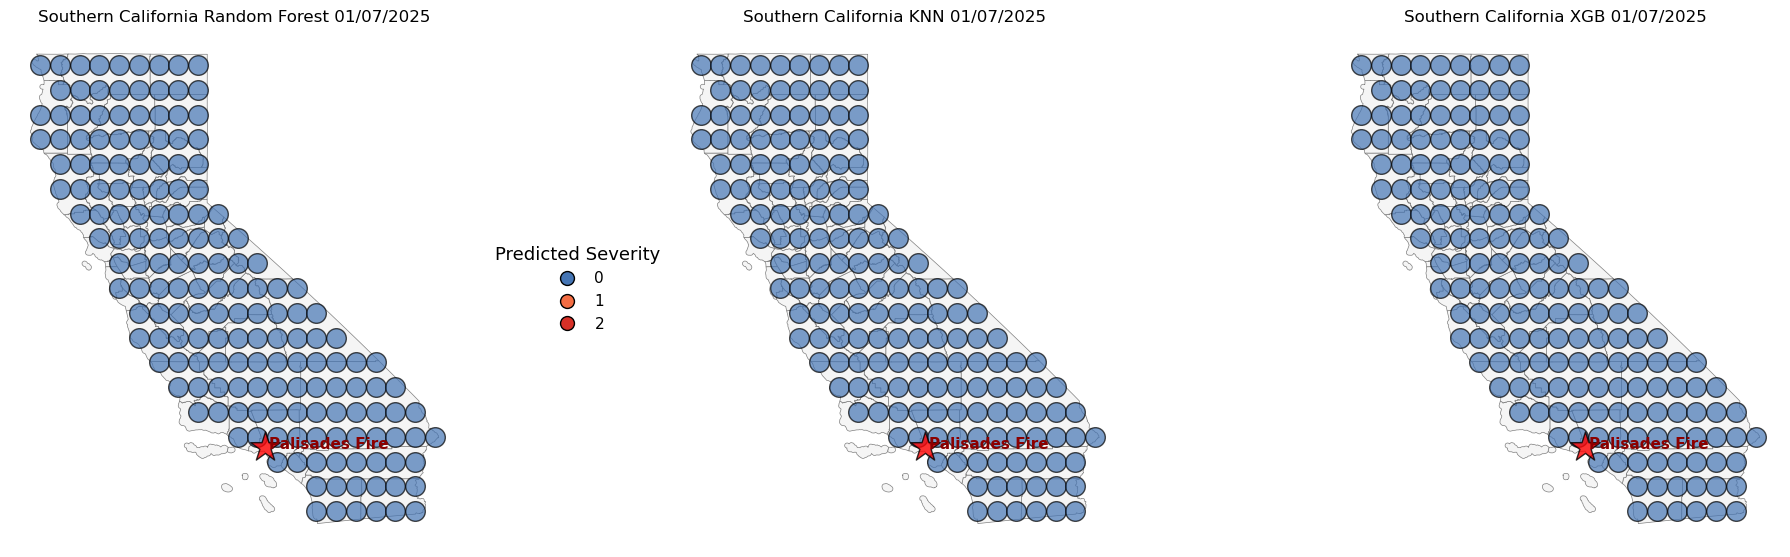

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))  # 1 row, 3 columns

# Plot into each subplot by passing in the axis
plot_map(pal_gdf, 'Prediction RF', 'Palisades', ax=axes[0])
plot_map(pal_gdf, 'Prediction KNN', 'Palisades', ax=axes[1])
plot_map(pal_gdf, 'Prediction XGB', 'Palisades', ax=axes[2])

# Set titles if plot_map doesn't do it
axes[0].set_title('Southern California Random Forest 01/07/2025')
axes[1].set_title('Southern California KNN 01/07/2025')
axes[2].set_title('Southern California XGB 01/07/2025')

plt.tight_layout()

#plt.savefig("../plots/Palisades_predictions.png", dpi=600)

### Interpolation

<img src="../data/maps/IDW_RF.jpg" width="600">